<div style="background:linear-gradient(135deg,#7a3d00 0%,#b45309 55%,#d97706 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#ffe9c7;font-weight:700;text-transform:uppercase">Chapter 3 · Solutions</div>
  <div style="font-size:36px;font-weight:900;line-height:1.1;margin:10px 0 6px">Practice Challenges — Worked Answers ✅</div>
  <div style="font-size:15px;color:#ffe6cc;max-width:700px;line-height:1.6">Full solutions to the six lifecycle challenges — one for each stage, beginner-to-intermediate. Try them yourself first, then compare.</div>
  <div style="margin-top:16px;font-size:13px;color:#ffe2bf">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
NAVY="#0a1230"; INK="#1a2138"; INK_SOFT="#4a5578"
CYAN="#0891b2"; PURPLE="#7c3aed"; AMBER="#d97706"; GREEN="#059669"; PINK="#db2777"; BLUE="#2563eb"; GRID="#e6e9f2"
plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
    "axes.edgecolor":GRID,"axes.linewidth":1.2,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,
    "axes.spines.top":False,"axes.spines.right":False,"axes.titlesize":14,"axes.titleweight":"bold","axes.titlecolor":INK,
    "axes.labelcolor":INK_SOFT,"xtick.color":INK_SOFT,"ytick.color":INK_SOFT,"legend.frameon":False})
print("✅ Ready.")

✅ Ready.


<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0891b2;letter-spacing:1px">CHALLENGE 1 · FRAME</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Turn a wish into a data question</div>
<div style="color:#4a5578;margin-top:6px">A gym says "we have too many cancellations." Rewrite this as a measurable data-science question with a target and a success metric.</div>
</div>

In [2]:
answer = {
  "Business need": "Reduce membership cancellations",
  "Data question": "Can we predict which members will cancel next month?",
  "Target (label)": "will_cancel  (yes / no)",
  "Success metric": "Accuracy / recall of catching cancellers before they leave",
}
for k, v in answer.items():
    print(f"{k:>16}: {v}")

   Business need: Reduce membership cancellations
   Data question: Can we predict which members will cancel next month?
  Target (label): will_cancel  (yes / no)
  Success metric: Accuracy / recall of catching cancellers before they leave


**Answer:** A good frame names *what* you predict (the target) and *how you'll know it worked* (the metric). "Reduce cancellations" → "predict `will_cancel`, measured by recall."

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">CHALLENGE 2 · COLLECT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Identify data & the target</div>
<div style="color:#4a5578;margin-top:6px">For that gym problem, name two useful data sources and state which column is the target (label).</div>
</div>

In [3]:
sources = ["Membership database (join date, plan, price)",
           "Check-in logs (how often each member visits)"]
target  = "will_cancel  (did the member cancel? yes/no)"
for s in sources: print("Data source:", s)
print("Target/label:", target)

Data source: Membership database (join date, plan, price)
Data source: Check-in logs (how often each member visits)
Target/label: will_cancel  (did the member cancel? yes/no)


**Answer:** Good sources tie directly to the question (visit frequency is a strong churn signal). The **target** is the thing you want to predict: `will_cancel`.

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#d97706;letter-spacing:1px">CHALLENGE 3 · CLEAN</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Tidy a messy table</div>
<div style="color:#4a5578;margin-top:6px">Clean this data: drop the duplicate row, then fill the missing age with the column mean.</div>
</div>

In [4]:
raw = pd.DataFrame({
    "name": ["Ana","Ben","Ben","Cara","Dan"],
    "age":  [34, 41, 41, None, 29],
})
print("RAW:"); print(raw)

clean = raw.drop_duplicates().reset_index(drop=True)
clean["age"] = clean["age"].fillna(round(clean["age"].mean(), 1))
print("\nCLEAN:"); print(clean)

RAW:
   name   age
0   Ana  34.0
1   Ben  41.0
2   Ben  41.0
3  Cara   NaN
4   Dan  29.0

CLEAN:
   name   age
0   Ana  34.0
1   Ben  41.0
2  Cara  34.7
3   Dan  29.0


**Answer:** Drop the repeated "Ben" row, then fill Cara's missing age with the mean of the known ages (≈ 34.7). Always clean *before* analyzing.

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#059669;letter-spacing:1px">CHALLENGE 4 · EXPLORE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Find the relationship</div>
<div style="color:#4a5578;margin-top:6px">Given hours of exercise per week and resting heart rate, compute the correlation and say what it means.</div>
</div>

Correlation = -1.00


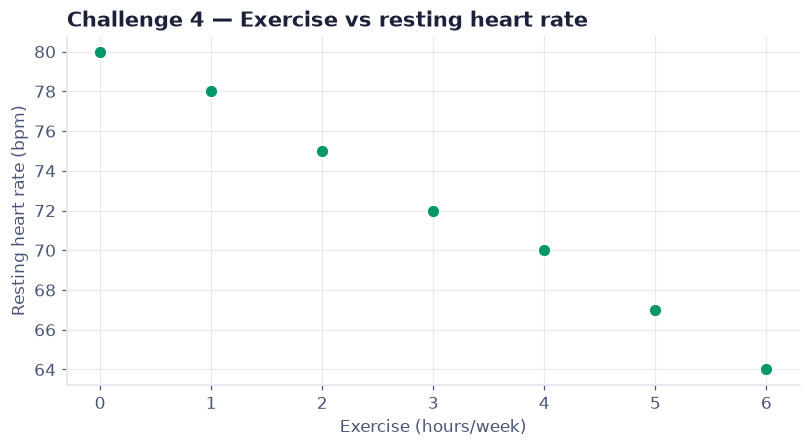

In [5]:
exercise = pd.Series([0, 1, 2, 3, 4, 5, 6])      # hours/week
heart    = pd.Series([80, 78, 75, 72, 70, 67, 64]) # resting bpm

corr = exercise.corr(heart)
print(f"Correlation = {corr:.2f}")

fig, ax = plt.subplots(figsize=(7.5,4.2))
ax.scatter(exercise, heart, color=GREEN, s=70, edgecolor="white")
ax.set_title("Challenge 4 — Exercise vs resting heart rate", loc="left")
ax.set_xlabel("Exercise (hours/week)"); ax.set_ylabel("Resting heart rate (bpm)")
plt.tight_layout(); plt.show()

**Answer:** Correlation ≈ **−0.99** — a strong *negative* relationship: more exercise is associated with a lower resting heart rate. (Correlation ≠ causation, but it's a strong lead.)

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#2563eb;letter-spacing:1px">CHALLENGE 5 · MODEL</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Fit a line and predict</div>
<div style="color:#4a5578;margin-top:6px">Fit a straight-line model to the exercise/heart-rate data, write the equation, and predict the heart rate for 3.5 hours/week.</div>
</div>

In [6]:
slope, intercept = np.polyfit(exercise, heart, 1)
print(f"Model:  heart_rate = {intercept:.1f} + ({slope:.1f}) * hours")

pred = slope*3.5 + intercept
print(f"Prediction at 3.5 hrs/week -> {pred:.1f} bpm")

Model:  heart_rate = 80.3 + (-2.7) * hours
Prediction at 3.5 hrs/week -> 70.9 bpm


**Answer:** The model is roughly `heart = 80 − 2.6 × hours`; at 3.5 hours it predicts ≈ **71 bpm**. Fitting the line is the "learning" step.

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#db2777;letter-spacing:1px">CHALLENGE 6 · EVALUATE &amp; DEPLOY</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Score the model</div>
<div style="color:#4a5578;margin-top:6px">A model predicted [70, 60, 80] but the true values were [72, 58, 85]. Compute the RMSE and say in one line how you'd keep it healthy in production.</div>
</div>

In [7]:
pred  = np.array([70, 60, 80])
actual= np.array([72, 58, 85])
rmse = np.sqrt(np.mean((actual - pred)**2))
print(f"RMSE = {rmse:.2f}  (typical error, in the same units as the target)")

RMSE = 3.32  (typical error, in the same units as the target)


**Answer:** RMSE ≈ **3.1**. In production you'd **monitor** the error over time — if it starts creeping up (data drift), loop back, collect fresh data, and retrain. That feedback loop is what makes the lifecycle a circle.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">🎉 Nicely done!</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">You framed a question, identified data, cleaned a table, explored a relationship, fit a model, and evaluated it — one challenge for every stage of the data science lifecycle.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>